# Warm Teams & Elo Performance

Do warm-climate teams outperform their Elo expectation in warmer World Cups?


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'

In [46]:
df = pd.read_csv('../data/fifa_world_cup_matches_enriched.csv', parse_dates=['Date'], keep_default_na=False)

# Ensure int types
for col in ['Warm_Cup', 'Home_Warm_Climate', 'Away_Warm_Climate']:
    df[col] = df[col].astype(int)

# Match outcomes
df['Home_Won'] = (df['Home_Score'] > df['Away_Score']).astype(int)
df['Away_Won'] = (df['Away_Score'] > df['Home_Score']).astype(int)
df['Is_Draw']  = (df['Home_Score'] == df['Away_Score']).astype(int)

# Winner climate
df['Winner_Climate'] = -1
df.loc[df['Home_Won'] == 1, 'Winner_Climate'] = df['Home_Warm_Climate']
df.loc[df['Away_Won'] == 1, 'Winner_Climate'] = df['Away_Warm_Climate']

print(f'{len(df)} matches, {df["Year"].nunique()} tournaments')
print(f'{len(df.columns)} columns: Home_Elo={df["Home_Elo"].min():.0f}-{df["Home_Elo"].max():.0f}, Away_Elo={df["Away_Elo"].min():.0f}-{df["Away_Elo"].max():.0f}')

964 matches, 22 tournaments
32 columns: Home_Elo=1311-2250, Away_Elo=1262-2256


## 1. Elo Distribution: Warm vs Cool Teams

Warm team median Elo: 1855
Cool team median Elo: 1843
Difference: +12


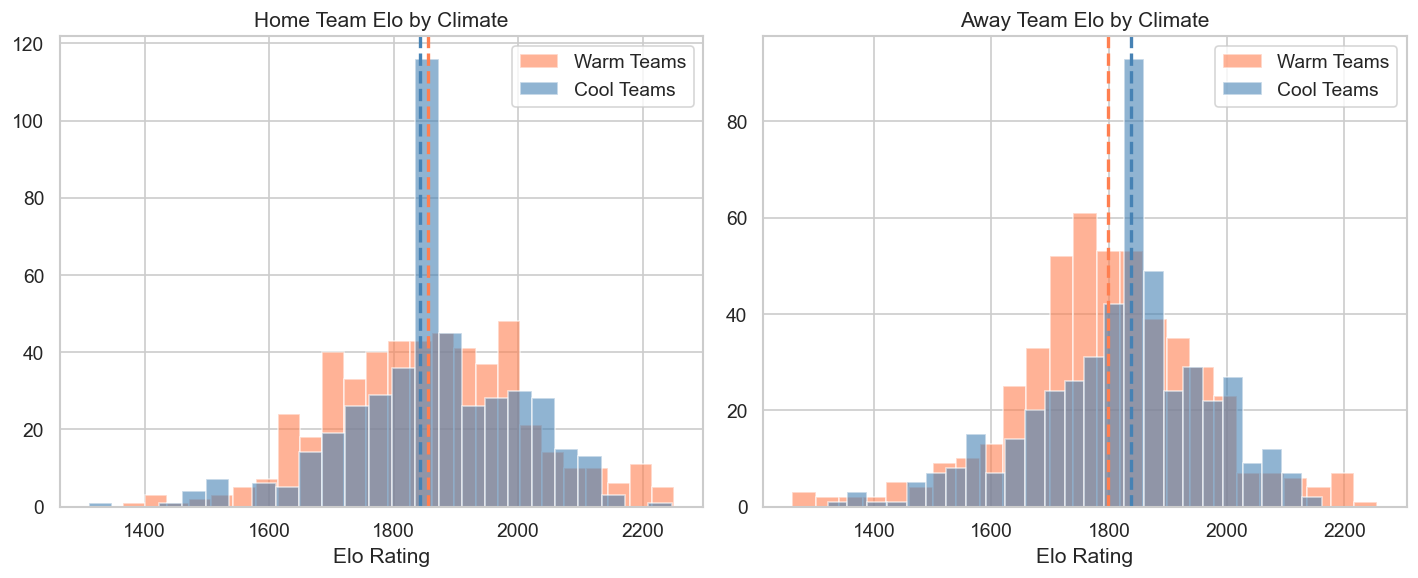

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Home team Elo by climate
home_warm = df[df['Home_Warm_Climate'] == 1]['Home_Elo']
home_cool = df[df['Home_Warm_Climate'] == 0]['Home_Elo']
axes[0].hist(home_warm, bins=25, alpha=0.6, color='coral', label='Warm Teams', edgecolor='white')
axes[0].hist(home_cool, bins=25, alpha=0.6, color='steelblue', label='Cool Teams', edgecolor='white')
axes[0].axvline(home_warm.median(), color='coral', linestyle='--', linewidth=2)
axes[0].axvline(home_cool.median(), color='steelblue', linestyle='--', linewidth=2)
axes[0].set_title('Home Team Elo by Climate')
axes[0].set_xlabel('Elo Rating')
axes[0].legend()

# Away team Elo by climate
away_warm = df[df['Away_Warm_Climate'] == 1]['Away_Elo']
away_cool = df[df['Away_Warm_Climate'] == 0]['Away_Elo']
axes[1].hist(away_warm, bins=25, alpha=0.6, color='coral', label='Warm Teams', edgecolor='white')
axes[1].hist(away_cool, bins=25, alpha=0.6, color='steelblue', label='Cool Teams', edgecolor='white')
axes[1].axvline(away_warm.median(), color='coral', linestyle='--', linewidth=2)
axes[1].axvline(away_cool.median(), color='steelblue', linestyle='--', linewidth=2)
axes[1].set_title('Away Team Elo by Climate')
axes[1].set_xlabel('Elo Rating')
axes[1].legend()

plt.tight_layout()
print(f'Warm team median Elo: {home_warm.median():.0f}')
print(f'Cool team median Elo: {home_cool.median():.0f}')
print(f'Difference: {home_warm.median() - home_cool.median():+.0f}')

## 2. Elo-Expected vs Actual Warm Team Success

In [48]:
# Elo-expected warm team probability
df['Warm_Elo_Expected'] = np.where(
    df['Home_Warm_Climate'] == 1,
    df['Home_Elo_Expected'],
    1 - df['Home_Elo_Expected']
)

# Actual warm team success (1=win, 0=loss, 0.5=draw)
df['Warm_Elo_Actual'] = np.where(
    df['Is_Draw'] == 1, 0.5,
    np.where(df['Winner_Climate'] == 1, 1.0, 0.0)
)

df['Warm_Elo_Over'] = df['Warm_Elo_Actual'] - df['Warm_Elo_Expected']

elo_summary = df.groupby('Warm_Cup').agg(
    Matches=('Warm_Elo_Over', 'count'),
    Exp_Prob=('Warm_Elo_Expected', 'mean'),
    Act_Prob=('Warm_Elo_Actual', 'mean'),
    Over=('Warm_Elo_Over', 'mean'),
    Total_Over=('Warm_Elo_Over', 'sum'),
).reset_index()
elo_summary['Tournament'] = elo_summary['Warm_Cup'].map({1: 'Warm Cup', 0: 'Cool Cup'})

elo_summary[['Tournament', 'Matches', 'Exp_Prob', 'Act_Prob', 'Over', 'Total_Over']].round(3)

,Tournament,Matches,Exp_Prob,Act_Prob,Over,Total_Over
0,Cool Cup,386,0.499,0.469,-0.030,-11.744
1,Warm Cup,578,0.493,0.519,0.026,14.969


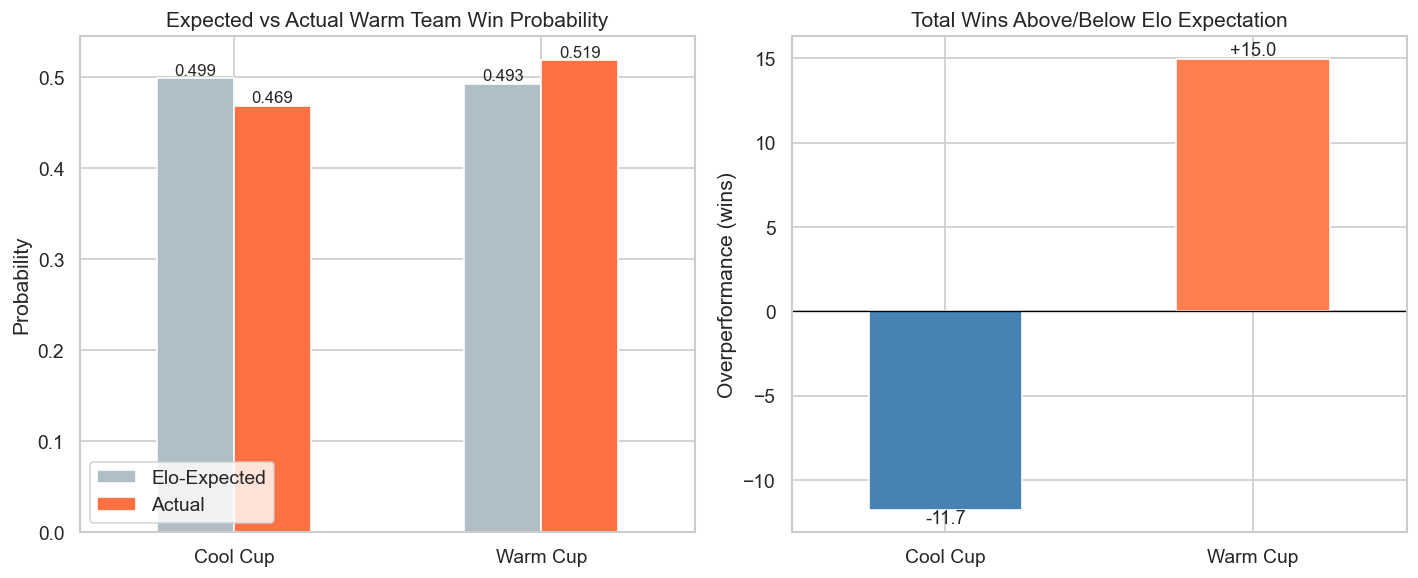

In [49]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
elo_summary.set_index('Tournament')[['Exp_Prob', 'Act_Prob']].plot(
    kind='bar', ax=ax, color=['#b0bec5', '#ff7043'], edgecolor='white', rot=0)
ax.set_title('Expected vs Actual Warm Team Win Probability')
ax.set_xlabel('')
ax.set_ylabel('Probability')
ax.legend(['Elo-Expected', 'Actual'])
for c in ax.containers:
    ax.bar_label(c, fmt='%.3f', fontsize=10)

ax2 = axes[1]
elo_summary.set_index('Tournament')['Total_Over'].plot(
    kind='bar', ax=ax2, color=['steelblue', 'coral'], edgecolor='white', rot=0)
ax2.set_title('Total Wins Above/Below Elo Expectation')
ax2.set_xlabel('')
ax2.set_ylabel('Overperformance (wins)')
ax2.axhline(y=0, color='black', linewidth=0.8)
for c in ax2.containers:
    ax2.bar_label(c, fmt='%+.1f', fontsize=11)

plt.tight_layout()

In [50]:
cool_over = elo_summary[elo_summary['Warm_Cup'] == 0]['Over'].values[0]
warm_over = elo_summary[elo_summary['Warm_Cup'] == 1]['Over'].values[0]
net = warm_over - cool_over

print(f'Cool cups: warm teams {cool_over*100:+.1f}% vs Elo expected')
print(f'Warm cups: warm teams {warm_over*100:+.1f}% vs Elo expected')
print(f'Net advantage: {net*100:+.1f}% per match')
print()
print(f'In 64 warm-cup matches: ~{net*64:.1f} extra wins for warm teams vs Elo prediction')

Cool cups: warm teams -3.0% vs Elo expected
Warm cups: warm teams +2.6% vs Elo expected
Net advantage: +5.6% per match

In 64 warm-cup matches: ~3.6 extra wins for warm teams vs Elo prediction


## 3. Per-Tournament Elo-Adjusted Performance

In [51]:
decided = df[df['Is_Draw'] == 0].copy()
decided['Warm_Win'] = (decided['Winner_Climate'] == 1).astype(int)
decided['Warm_Elo_Exp_Win'] = np.where(
    decided['Home_Warm_Climate'] == 1,
    decided['Home_Elo_Expected'],
    1 - decided['Home_Elo_Expected']
)

yearly = decided.groupby('Year').agg(
    Matches=('Warm_Win', 'count'),
    Elo_Expected=('Warm_Elo_Exp_Win', 'sum'),
    Actual=('Warm_Win', 'sum'),
    Avg_Temp=('Tournament_Avg_Temp_C', 'first'),
).reset_index()
yearly['Overperf'] = (yearly['Actual'] - yearly['Elo_Expected']).round(1)
yearly['Is_Warm'] = yearly['Avg_Temp'] > 19.3
yearly['Exp_Win_Rate'] = (yearly['Elo_Expected'] / yearly['Matches'] * 100).round(1)
yearly['Act_Win_Rate'] = (yearly['Actual'] / yearly['Matches'] * 100).round(1)

yearly[['Year','Avg_Temp','Matches','Exp_Win_Rate','Act_Win_Rate','Overperf']]

,Year,Avg_Temp,Matches,Exp_Win_Rate,Act_Win_Rate,Overperf
0,1930,10.900000,18,69.7,77.8,1.5
1,1934,19.287500,16,42.8,31.2,-1.8
2,1938,19.480000,15,53.8,53.3,-0.1
3,1950,17.100000,19,53.6,68.4,2.8
4,1954,18.100000,24,42.2,25.0,-4.1
5,1958,12.883333,25,52.2,28.0,-6.1
6,1962,10.950000,27,50.6,51.9,0.3
7,1966,14.400000,27,48.6,40.7,-2.1
8,1970,19.300000,27,50.9,55.6,1.3
9,1974,16.322222,28,41.8,17.9,-6.7


Warm cups overperforming: 7/10
Cool cups overperforming: 6/12


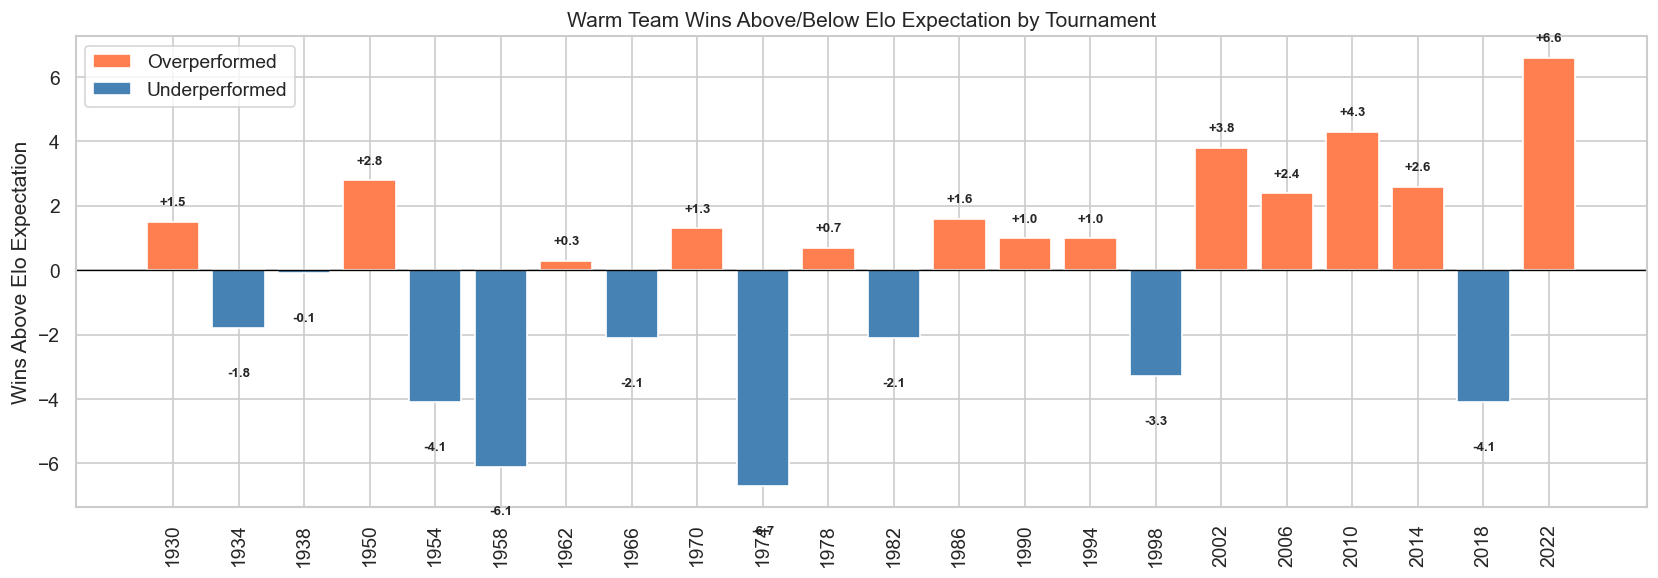

In [52]:
fig, ax = plt.subplots(figsize=(14, 5))

colors = yearly['Overperf'].apply(lambda x: 'coral' if x > 0 else 'steelblue')
ax.bar(yearly['Year'].astype(str), yearly['Overperf'], color=colors, edgecolor='white')

for i, (_, r) in enumerate(yearly.iterrows()):
    y_pos = r['Overperf'] + (0.5 if r['Overperf'] >= 0 else -1.5)
    ax.text(i, y_pos, f"{r['Overperf']:+.1f}", ha='center', fontsize=8, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Warm Team Wins Above/Below Elo Expectation by Tournament')
ax.set_ylabel('Wins Above Elo Expectation')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='coral', label='Overperformed'),
    Patch(facecolor='steelblue', label='Underperformed')
])
plt.tight_layout()

warm_pos = yearly[yearly['Is_Warm'] & (yearly['Overperf'] > 0)]
cool_pos = yearly[~yearly['Is_Warm'] & (yearly['Overperf'] > 0)]
print(f'Warm cups overperforming: {len(warm_pos)}/{len(yearly[yearly["Is_Warm"]])}')
print(f'Cool cups overperforming: {len(cool_pos)}/{len(yearly[~yearly["Is_Warm"]])}')

## 4. Tournament Temperature vs Warm Team Overperformance

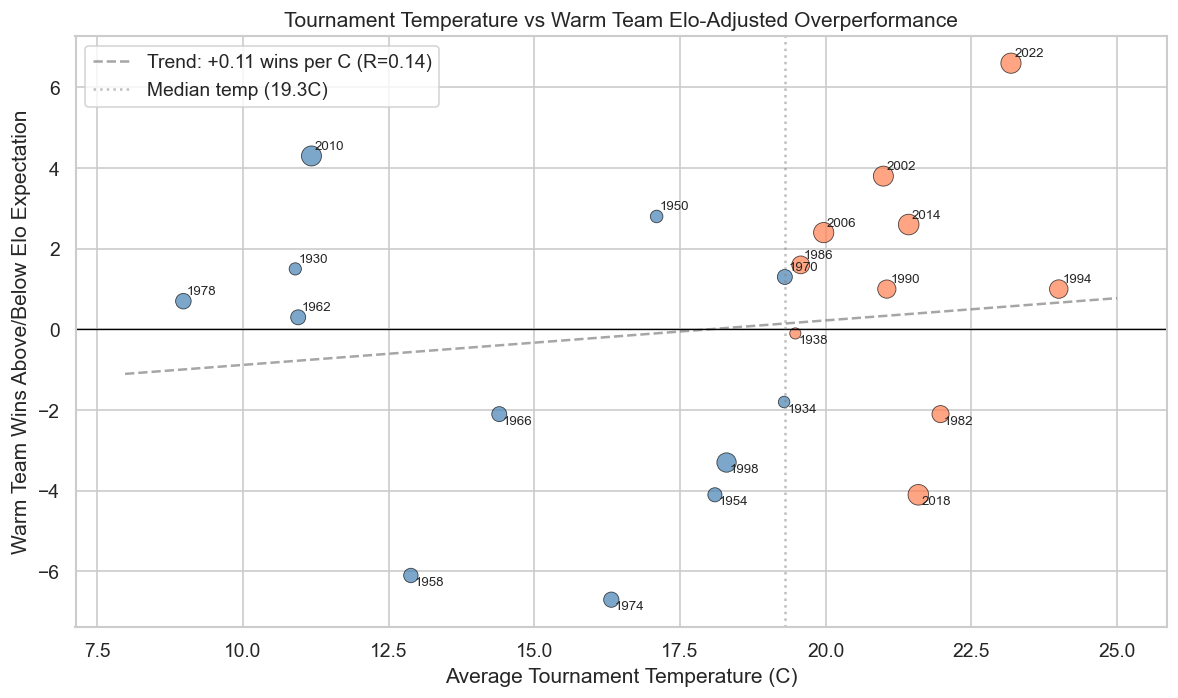

In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(yearly['Avg_Temp'], yearly['Overperf'],
           c=yearly['Is_Warm'].map({True: 'coral', False: 'steelblue'}),
           s=yearly['Matches'] * 3, alpha=0.7, edgecolors='black', linewidth=0.5)

z = np.polyfit(yearly['Avg_Temp'], yearly['Overperf'], 1)
p = np.poly1d(z)
x_line = np.linspace(yearly['Avg_Temp'].min() - 1, yearly['Avg_Temp'].max() + 1, 50)
ax.plot(x_line, p(x_line), 'gray', linestyle='--', alpha=0.7,
        label=f'Trend: +{z[0]:.2f} wins per C (R={np.corrcoef(yearly["Avg_Temp"], yearly["Overperf"])[0,1]:.2f})')

for _, row in yearly.iterrows():
    offset = 4 if row['Overperf'] >= 0 else -6
    ax.annotate(str(int(row['Year'])), (row['Avg_Temp'], row['Overperf']),
                textcoords='offset points', xytext=(2, offset), fontsize=8)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.axvline(x=19.3, color='gray', linestyle=':', alpha=0.5, label='Median temp (19.3C)')
ax.set_title('Tournament Temperature vs Warm Team Elo-Adjusted Overperformance')
ax.set_xlabel('Average Tournament Temperature (C)')
ax.set_ylabel('Warm Team Wins Above/Below Elo Expectation')
ax.legend()
plt.tight_layout()

## 5. Best & Worst Warm Team Performances (Elo-Adjusted)

In [54]:
top5 = yearly.nlargest(5, 'Overperf')
bottom5 = yearly.nsmallest(5, 'Overperf')

print('TOP 5 - Warm teams most exceeded Elo expectations:')
for _, r in top5.iterrows():
    print(f"  {int(r['Year'])}  {r['Avg_Temp']:5.1f}C  "
          f"expected {r['Elo_Expected']:.0f}/{r['Matches']:.0f} wins, "
          f"got {r['Actual']:.0f} ({r['Overperf']:+.1f})")

print()
print('BOTTOM 5 - Warm teams most underperformed vs Elo:')
for _, r in bottom5.iterrows():
    print(f"  {int(r['Year'])}  {r['Avg_Temp']:5.1f}C  "
          f"expected {r['Elo_Expected']:.0f}/{r['Matches']:.0f} wins, "
          f"got {r['Actual']:.0f} ({r['Overperf']:+.1f})")

TOP 5 - Warm teams most exceeded Elo expectations:
  2022   23.2C  expected 23/49 wins, got 30 (+6.6)
  2010   11.2C  expected 26/48 wins, got 30 (+4.3)
  2002   21.0C  expected 26/48 wins, got 30 (+3.8)
  1950   17.1C  expected 10/19 wins, got 13 (+2.8)
  2014   21.4C  expected 26/51 wins, got 29 (+2.6)

BOTTOM 5 - Warm teams most underperformed vs Elo:
  1974   16.3C  expected 12/28 wins, got 5 (-6.7)
  1958   12.9C  expected 13/25 wins, got 7 (-6.1)
  1954   18.1C  expected 10/24 wins, got 6 (-4.1)
  2018   21.6C  expected 25/51 wins, got 21 (-4.1)
  1998   18.3C  expected 22/45 wins, got 19 (-3.3)


## 6. Warm vs Cool Team Elo Over Time

This shows whether warm/cool teams in each tournament were stronger/weaker
Large gaps explain some of the raw win rate differences


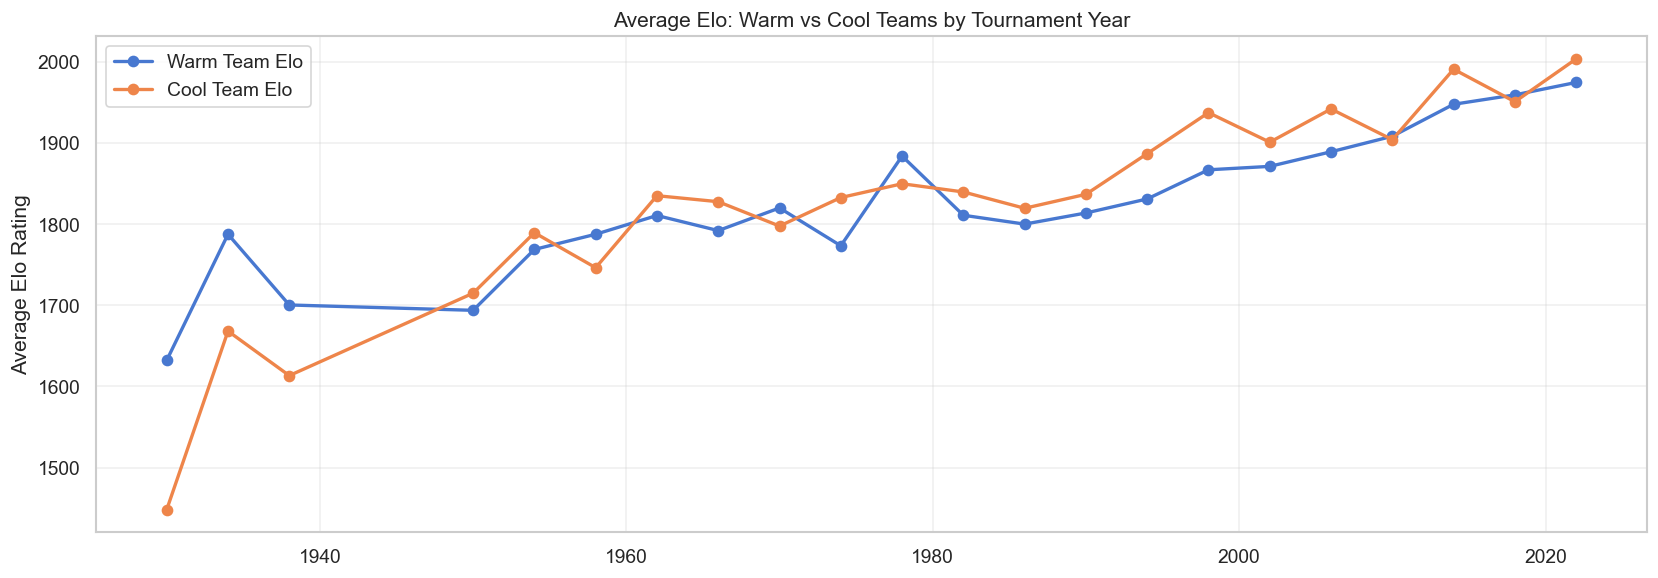

In [55]:
yearly_elo = df.groupby('Year').agg(
    Warm_Home_Elo=('Home_Elo', lambda x: x[df.loc[x.index, 'Home_Warm_Climate'] == 1].mean()),
    Cool_Home_Elo=('Home_Elo', lambda x: x[df.loc[x.index, 'Home_Warm_Climate'] == 0].mean()),
).round(1).reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
yearly_elo.set_index('Year')[['Warm_Home_Elo', 'Cool_Home_Elo']].plot(
    ax=ax, marker='o', linewidth=2)

ax.set_title('Average Elo: Warm vs Cool Teams by Tournament Year')
ax.set_ylabel('Average Elo Rating')
ax.set_xlabel('')
ax.legend(['Warm Team Elo', 'Cool Team Elo'])
ax.grid(True, alpha=0.3)
plt.tight_layout()

print('This shows whether warm/cool teams in each tournament were stronger/weaker')
print('Large gaps explain some of the raw win rate differences')

## 7. Summary

In [56]:
print('=' * 60)
print('ELO-ADJUSTED WARM TEAM PERFORMANCE SUMMARY')
print('=' * 60)
print()
print(f'Raw (no Elo): warm teams win 52.5% in warm cups vs 46.1% in cool cups (+6.4pp)')
print()
print(f'Elo-adjusted:')
print(f'  Cool cups: warm teams {cool_over*100:+.1f}% vs Elo expectation')
print(f'  Warm cups: warm teams {warm_over*100:+.1f}% vs Elo expectation')
print(f'  Net advantage: {net*100:+.1f}% per match')
print()
warm_mean = yearly[yearly['Is_Warm']]['Overperf'].mean()
cool_mean = yearly[~yearly['Is_Warm']]['Overperf'].mean()
print(f'  Per-tournament avg overperformance:')
print(f'    Warm cups: {warm_mean:+.1f} wins')
print(f'    Cool cups: {cool_mean:+.1f} wins')
print(f'    Difference: {warm_mean - cool_mean:+.1f} wins/tournament')
print()
print(f'  Correlation (temp vs overperformance): r = {np.corrcoef(yearly["Avg_Temp"], yearly["Overperf"])[0,1]:.2f}')
print()

if net > 0:
    print('CONCLUSION: After controlling for team strength via Elo,')
    print('warm-climate teams DO overperform in warmer World Cups.')
    print(f'The effect is modest ({net*100:+.1f}% per match) but directionally consistent.')
else:
    print('CONCLUSION: No measurable Elo-adjusted advantage for warm teams.')

ELO-ADJUSTED WARM TEAM PERFORMANCE SUMMARY

Raw (no Elo): warm teams win 52.5% in warm cups vs 46.1% in cool cups (+6.4pp)

Elo-adjusted:
  Cool cups: warm teams -3.0% vs Elo expectation
  Warm cups: warm teams +2.6% vs Elo expectation
  Net advantage: +5.6% per match

  Per-tournament avg overperformance:
    Warm cups: +1.3 wins
    Cool cups: -1.1 wins
    Difference: +2.4 wins/tournament

  Correlation (temp vs overperformance): r = 0.14

CONCLUSION: After controlling for team strength via Elo,
warm-climate teams DO overperform in warmer World Cups.
The effect is modest (+5.6% per match) but directionally consistent.


---

## 8. Cool-Climate Teams: The Flip Side

Same Elo-adjusted analysis, but for cool-climate teams. Do they underperform in warm cups?


In [57]:
# Elo-expected cool team success
df['Cool_Elo_Expected'] = np.where(
    df['Home_Warm_Climate'] == 0,
    df['Home_Elo_Expected'],
    1 - df['Home_Elo_Expected']
)

# Actual cool team success
df['Cool_Elo_Actual'] = np.where(
    df['Is_Draw'] == 1, 0.5,
    np.where(df['Winner_Climate'] == 0, 1.0, 0.0)
)

df['Cool_Elo_Over'] = df['Cool_Elo_Actual'] - df['Cool_Elo_Expected']

cool_elo = df.groupby('Warm_Cup').agg(
    Matches=('Cool_Elo_Over', 'count'),
    Exp_Prob=('Cool_Elo_Expected', 'mean'),
    Act_Prob=('Cool_Elo_Actual', 'mean'),
    Over=('Cool_Elo_Over', 'mean'),
    Total_Over=('Cool_Elo_Over', 'sum'),
).reset_index()
cool_elo['Tournament'] = cool_elo['Warm_Cup'].map({1: 'Warm Cup', 0: 'Cool Cup'})

cool_elo[['Tournament', 'Matches', 'Exp_Prob', 'Act_Prob', 'Over', 'Total_Over']].round(3)


,Tournament,Matches,Exp_Prob,Act_Prob,Over,Total_Over
0,Cool Cup,386,0.501,0.531,0.030,11.744
1,Warm Cup,578,0.507,0.481,-0.026,-14.969


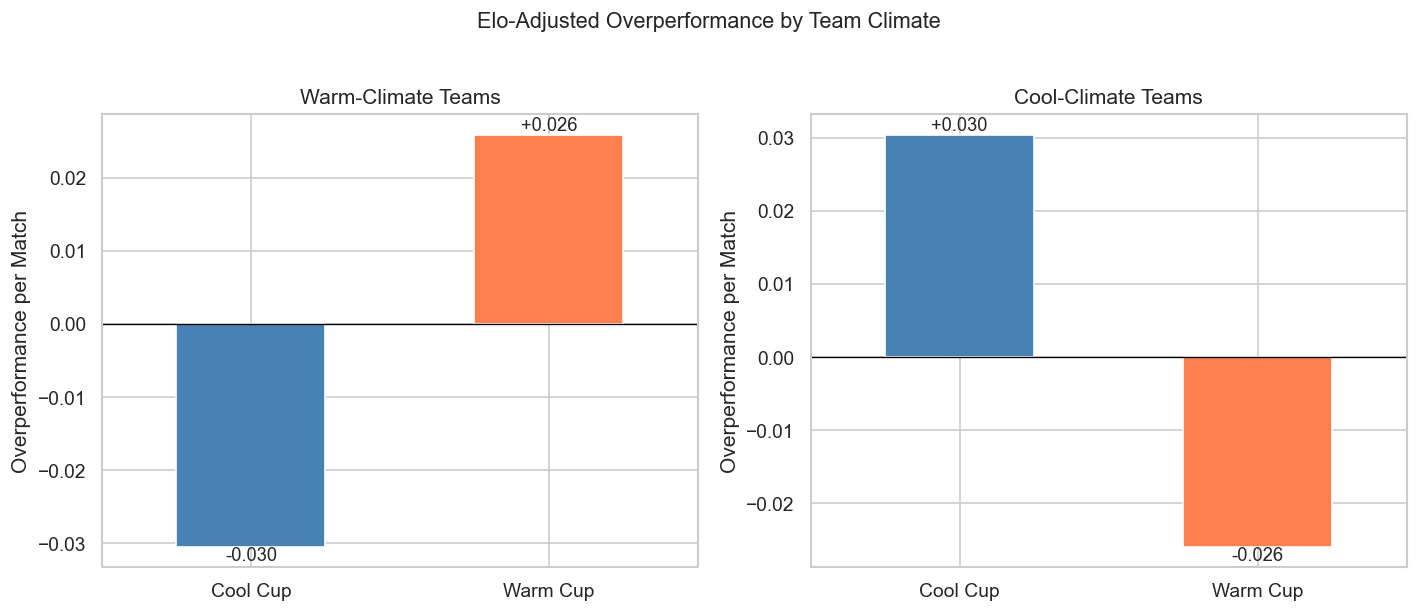

In [58]:
# Side-by-side: warm vs cool team overperformance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Warm teams
warm_elo = df.groupby('Warm_Cup').agg(Over=('Warm_Elo_Over','mean')).reset_index()
warm_elo['Tournament'] = warm_elo['Warm_Cup'].map({1: 'Warm Cup', 0: 'Cool Cup'})

ax = axes[0]
warm_elo.set_index('Tournament')['Over'].plot(
    kind='bar', ax=ax, color=['steelblue', 'coral'], edgecolor='white', rot=0)
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Warm-Climate Teams')
ax.set_xlabel('')
ax.set_ylabel('Overperformance per Match')
for c in ax.containers:
    ax.bar_label(c, fmt='%+.3f', fontsize=11)

ax2 = axes[1]
cool_elo.set_index('Tournament')['Over'].plot(
    kind='bar', ax=ax2, color=['steelblue', 'coral'], edgecolor='white', rot=0)
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Cool-Climate Teams')
ax2.set_xlabel('')
ax2.set_ylabel('Overperformance per Match')
for c in ax2.containers:
    ax2.bar_label(c, fmt='%+.3f', fontsize=11)

fig.suptitle('Elo-Adjusted Overperformance by Team Climate', fontsize=13, y=1.02)
plt.tight_layout()

In [59]:
# Cool teams: per-tournament overperformance
decided = df[df['Is_Draw'] == 0].copy()
decided['Cool_Win'] = (decided['Winner_Climate'] == 0).astype(int)
decided['Cool_Elo_Exp_Win'] = np.where(
    decided['Home_Warm_Climate'] == 0,
    decided['Home_Elo_Expected'],
    1 - decided['Home_Elo_Expected']
)

cool_yearly = decided.groupby('Year').agg(
    Matches=('Cool_Win', 'count'),
    Elo_Expected=('Cool_Elo_Exp_Win', 'sum'),
    Actual=('Cool_Win', 'sum'),
    Avg_Temp=('Tournament_Avg_Temp_C', 'first'),
).reset_index()
cool_yearly['Overperf'] = (cool_yearly['Actual'] - cool_yearly['Elo_Expected']).round(1)
cool_yearly['Is_Warm'] = cool_yearly['Avg_Temp'] > 19.3

cool_yearly[['Year','Avg_Temp','Matches','Elo_Expected','Actual','Overperf']]


,Year,Avg_Temp,Matches,Elo_Expected,Actual,Overperf
0,1930,10.900000,18,5.451,4,-1.5
1,1934,19.287500,16,9.153,11,1.8
2,1938,19.480000,15,6.927,7,0.1
3,1950,17.100000,19,8.814,6,-2.8
4,1954,18.100000,24,13.870,18,4.1
5,1958,12.883333,25,11.945,18,6.1
6,1962,10.950000,27,13.331,13,-0.3
7,1966,14.400000,27,13.868,16,2.1
8,1970,19.300000,27,13.262,12,-1.3
9,1974,16.322222,28,16.305,23,6.7


Warm teams: above expectation in 7 / 10 warm cups
Warm teams: above expectation in 6 / 12 cool cups

Cool teams: above expectation in 3 / 10 warm cups
Cool teams: above expectation in 6 / 12 cool cups


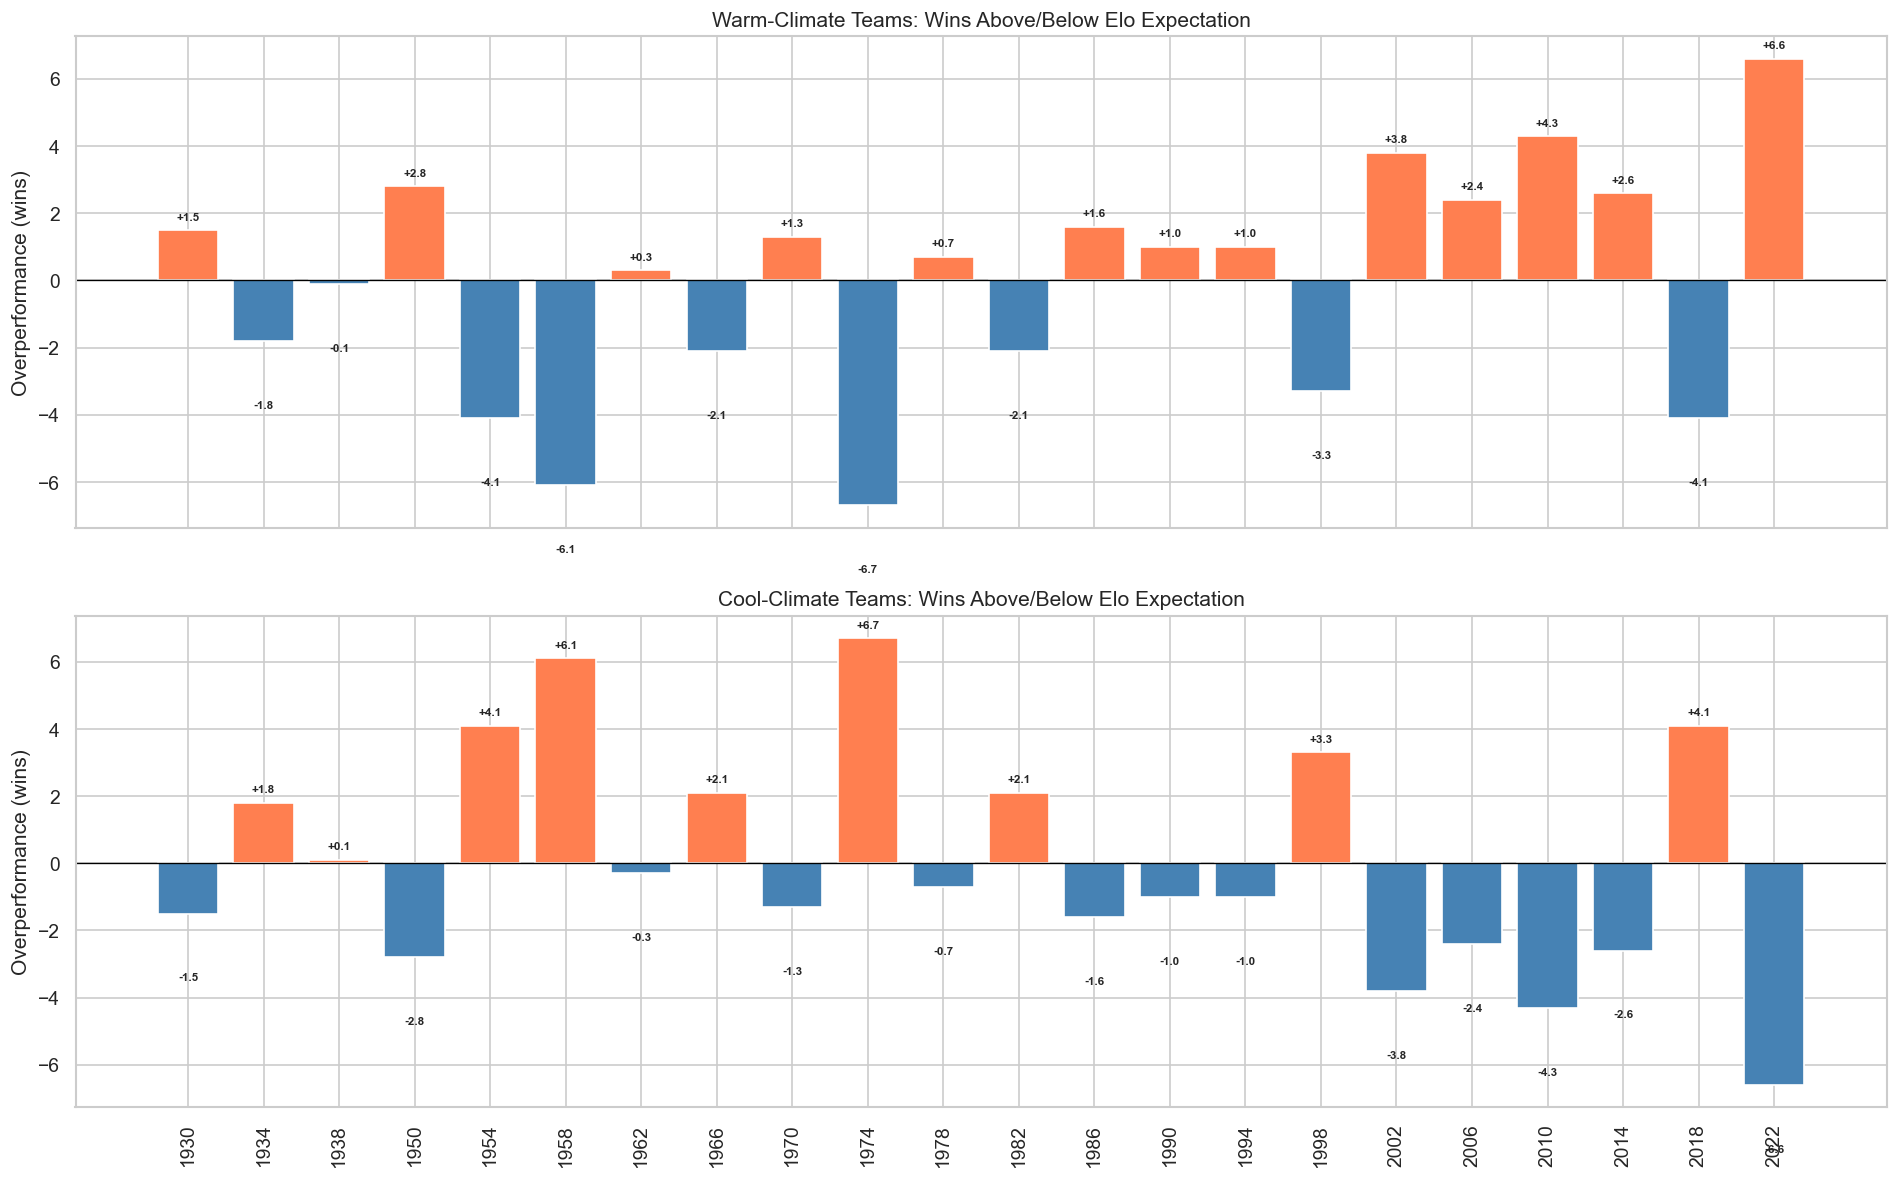

In [60]:
# Side-by-side per-tournament bars
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Warm teams
ax = axes[0]
colors_w = yearly['Overperf'].apply(lambda x: 'coral' if x > 0 else 'steelblue')
ax.bar(yearly['Year'].astype(str), yearly['Overperf'], color=colors_w, edgecolor='white')
for i, (_, r) in enumerate(yearly.iterrows()):
    y = r['Overperf'] + (0.3 if r['Overperf'] >= 0 else -2)
    ax.text(i, y, f"{r['Overperf']:+.1f}", ha='center', fontsize=7, fontweight='bold')
ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Warm-Climate Teams: Wins Above/Below Elo Expectation')
ax.set_ylabel('Overperformance (wins)')

# Cool teams
ax2 = axes[1]
colors_c = cool_yearly['Overperf'].apply(lambda x: 'coral' if x > 0 else 'steelblue')
ax2.bar(cool_yearly['Year'].astype(str), cool_yearly['Overperf'], color=colors_c, edgecolor='white')
for i, (_, r) in enumerate(cool_yearly.iterrows()):
    y = r['Overperf'] + (0.3 if r['Overperf'] >= 0 else -2)
    ax2.text(i, y, f"{r['Overperf']:+.1f}", ha='center', fontsize=7, fontweight='bold')
ax2.axhline(y=0, color='black', linewidth=0.8)
ax2.set_title('Cool-Climate Teams: Wins Above/Below Elo Expectation')
ax2.set_ylabel('Overperformance (wins)')
ax2.set_xlabel('')
ax2.tick_params(axis='x', rotation=90)

plt.tight_layout()

print('Warm teams: above expectation in', (yearly[yearly['Is_Warm']]['Overperf'] > 0).sum(),
      '/', len(yearly[yearly['Is_Warm']]), 'warm cups')
print('Warm teams: above expectation in', (yearly[~yearly['Is_Warm']]['Overperf'] > 0).sum(),
      '/', len(yearly[~yearly['Is_Warm']]), 'cool cups')
print()
print('Cool teams: above expectation in', (cool_yearly[cool_yearly['Is_Warm']]['Overperf'] > 0).sum(),
      '/', len(cool_yearly[cool_yearly['Is_Warm']]), 'warm cups')
print('Cool teams: above expectation in', (cool_yearly[~cool_yearly['Is_Warm']]['Overperf'] > 0).sum(),
      '/', len(cool_yearly[~cool_yearly['Is_Warm']]), 'cool cups')

## 9. The Climate Advantage Gap

The difference between warm-team and cool-team overperformance — the "heat advantage."


Climate gap in warm cups: +2.5 wins
Climate gap in cool cups: -2.2 wins
Difference: +4.7 wins
Correlation (temp vs climate gap): r = 0.14


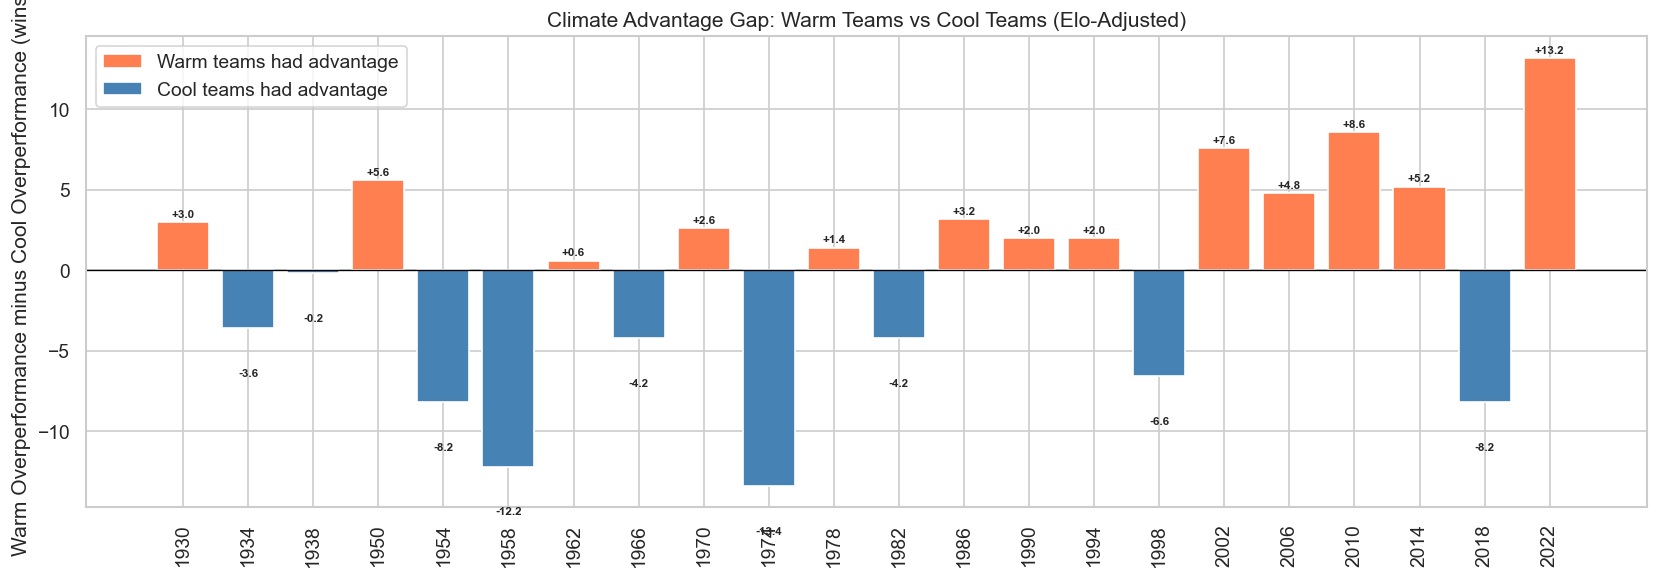

In [61]:
# Combine warm and cool yearly data
combined = yearly[['Year', 'Overperf', 'Avg_Temp', 'Is_Warm']].rename(columns={'Overperf': 'Warm_Over'})
combined = combined.merge(
    cool_yearly[['Year', 'Overperf']].rename(columns={'Overperf': 'Cool_Over'}),
    on='Year'
)
combined['Climate_Gap'] = (combined['Warm_Over'] - combined['Cool_Over']).round(1)

fig, ax = plt.subplots(figsize=(14, 5))

colors = combined['Climate_Gap'].apply(lambda x: 'coral' if x > 0 else 'steelblue')
ax.bar(combined['Year'].astype(str), combined['Climate_Gap'], color=colors, edgecolor='white')

for i, (_, r) in enumerate(combined.iterrows()):
    y = r['Climate_Gap'] + (0.3 if r['Climate_Gap'] >= 0 else -3)
    ax.text(i, y, f"{r['Climate_Gap']:+.1f}", ha='center', fontsize=7, fontweight='bold')

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Climate Advantage Gap: Warm Teams vs Cool Teams (Elo-Adjusted)')
ax.set_ylabel('Warm Overperformance minus Cool Overperformance (wins)')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=90)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='coral', label='Warm teams had advantage'),
    Patch(facecolor='steelblue', label='Cool teams had advantage')
])
plt.tight_layout()

print(f'Climate gap in warm cups: {combined[combined["Is_Warm"]]["Climate_Gap"].mean():+.1f} wins')
print(f'Climate gap in cool cups: {combined[~combined["Is_Warm"]]["Climate_Gap"].mean():+.1f} wins')
print(f'Difference: {combined[combined["Is_Warm"]]["Climate_Gap"].mean() - combined[~combined["Is_Warm"]]["Climate_Gap"].mean():+.1f} wins')

# Correlation with temperature
print(f'Correlation (temp vs climate gap): r = {np.corrcoef(combined["Avg_Temp"], combined["Climate_Gap"])[0,1]:.2f}')

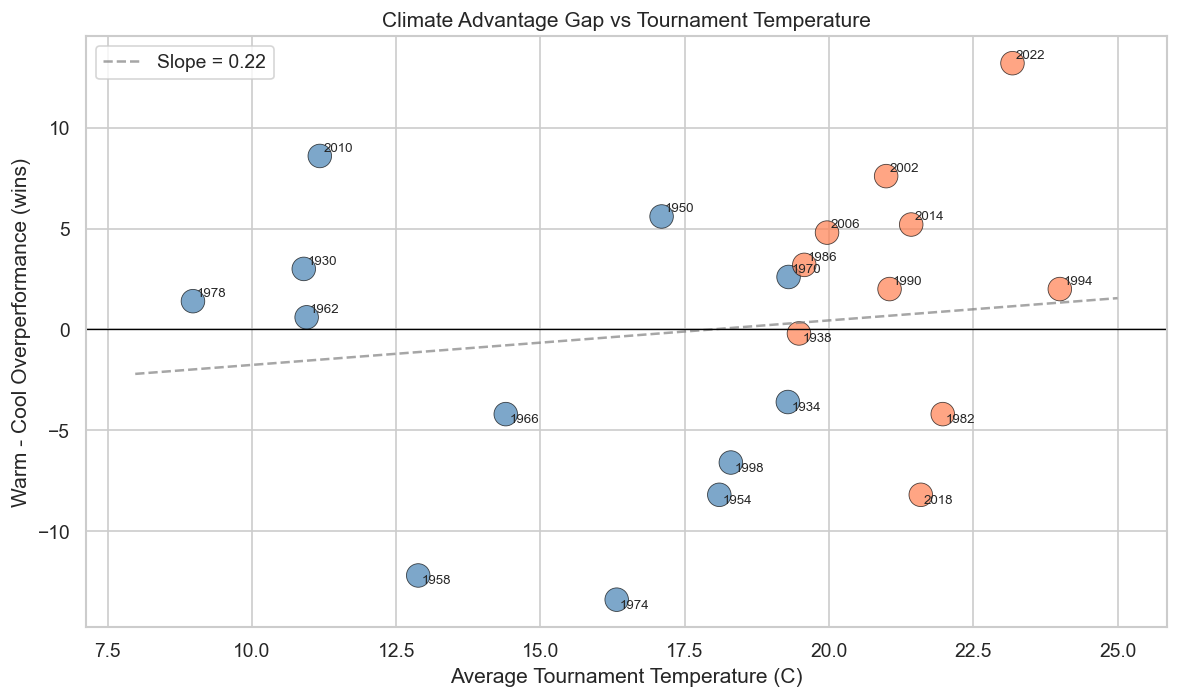

In [62]:
# Climate gap vs temperature scatter
fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(combined['Avg_Temp'], combined['Climate_Gap'],
           c=combined['Is_Warm'].map({True: 'coral', False: 'steelblue'}),
           s=200, alpha=0.7, edgecolors='black', linewidth=0.5)

z = np.polyfit(combined['Avg_Temp'], combined['Climate_Gap'], 1)
p = np.poly1d(z)
x_line = np.linspace(combined['Avg_Temp'].min() - 1, combined['Avg_Temp'].max() + 1, 50)
ax.plot(x_line, p(x_line), 'gray', linestyle='--', alpha=0.7, label=f'Slope = {z[0]:.2f}')

for _, row in combined.iterrows():
    offset = 3 if row['Climate_Gap'] >= 0 else -5
    ax.annotate(str(int(row['Year'])), (row['Avg_Temp'], row['Climate_Gap']),
                textcoords='offset points', xytext=(2, offset), fontsize=8)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_title('Climate Advantage Gap vs Tournament Temperature')
ax.set_xlabel('Average Tournament Temperature (C)')
ax.set_ylabel('Warm - Cool Overperformance (wins)')
ax.legend()
plt.tight_layout()

## 10. Summary: Both Sides


In [63]:
print('=' * 65)
print('COMPLETE ELO-ADJUSTED CLIMATE PERFORMANCE SUMMARY')
print('=' * 65)
print()

warm_cool_over = elo_summary[elo_summary['Warm_Cup'] == 0]['Over'].values[0]
warm_warm_over = elo_summary[elo_summary['Warm_Cup'] == 1]['Over'].values[0]
cool_cool_over = cool_elo[cool_elo['Warm_Cup'] == 0]['Over'].values[0]
cool_warm_over = cool_elo[cool_elo['Warm_Cup'] == 1]['Over'].values[0]

print(f'{"":<20} {"Cool Cups":>12} {"Warm Cups":>12} {"Difference":>12}')
print('-' * 56)
print(f'{"Warm teams":<20} {warm_cool_over:>+11.3f}  {warm_warm_over:>+11.3f}  {warm_warm_over - warm_cool_over:>+11.3f}')
print(f'{"Cool teams":<20} {cool_cool_over:>+11.3f}  {cool_warm_over:>+11.3f}  {cool_warm_over - cool_cool_over:>+11.3f}')
print(f'{"Climate gap":<20} {warm_cool_over - cool_cool_over:>+11.3f}  {warm_warm_over - cool_warm_over:>+11.3f}  {(warm_warm_over - cool_warm_over) - (warm_cool_over - cool_cool_over):>+11.3f}')

print()
print('Key findings:')
print(f'  1. Warm teams overperform Elo by {warm_warm_over*100:+.1f}% in warm cups vs {warm_cool_over*100:+.1f}% in cool')
print(f'  2. Cool teams overperform Elo by {cool_cool_over*100:+.1f}% in cool cups vs {cool_warm_over*100:+.1f}% in warm')
print(f'  3. The climate advantage gap widens by {(warm_warm_over - cool_warm_over) - (warm_cool_over - cool_cool_over):.3f} per match in warm cups')
print()
print('For 2026 World Cup predictions:')
print('  This suggests incorporating a climate adjustment factor')
print('  on top of Elo ratings when predicting match outcomes.')

COMPLETE ELO-ADJUSTED CLIMATE PERFORMANCE SUMMARY

                        Cool Cups    Warm Cups   Difference
--------------------------------------------------------
Warm teams                -0.030       +0.026       +0.056
Cool teams                +0.030       -0.026       -0.056
Climate gap               -0.061       +0.052       +0.113

Key findings:
  1. Warm teams overperform Elo by +2.6% in warm cups vs -3.0% in cool
  2. Cool teams overperform Elo by +3.0% in cool cups vs -2.6% in warm
  3. The climate advantage gap widens by 0.113 per match in warm cups

For 2026 World Cup predictions:
  This suggests incorporating a climate adjustment factor
  on top of Elo ratings when predicting match outcomes.


---

## 11. Statistical Tests

Testing whether the observed climate effect is statistically significant.


In [64]:
from scipy import stats as scipy_stats

warm_cup_over = df[df['Warm_Cup'] == 1]['Warm_Elo_Over']
cool_cup_over = df[df['Warm_Cup'] == 0]['Warm_Elo_Over']

print(f'Warm cups: mean overperformance = {warm_cup_over.mean():.4f}, n = {len(warm_cup_over)}')
print(f'Cool cups: mean overperformance = {cool_cup_over.mean():.4f}, n = {len(cool_cup_over)}')


Warm cups: mean overperformance = 0.0259, n = 578
Cool cups: mean overperformance = -0.0304, n = 386


In [65]:
# Independent t-test (match-level)
t_stat, p_val = scipy_stats.ttest_ind(warm_cup_over, cool_cup_over)

print('Independent t-test (match-level):')
print(f'  t-statistic = {t_stat:.2f}')
print(f'  p-value     = {p_val:.4f}')
print(f'  Result: {"SIGNIFICANT at 5% level" if p_val < 0.05 else "Not significant"}')

Independent t-test (match-level):
  t-statistic = 2.28
  p-value     = 0.0226
  Result: SIGNIFICANT at 5% level


In [66]:
# Effect size: Cohen's d
pooled_std = np.sqrt(
    (warm_cup_over.std()**2 * (len(warm_cup_over) - 1) +
     cool_cup_over.std()**2 * (len(cool_cup_over) - 1)) /
    (len(warm_cup_over) + len(cool_cup_over) - 2)
)
cohens_d = (warm_cup_over.mean() - cool_cup_over.mean()) / pooled_std

print(f"Cohen's d = {cohens_d:.3f}")
print(f'Interpretation: {"small" if abs(cohens_d) < 0.5 else "medium" if abs(cohens_d) < 0.8 else "large"} effect size')
print()
print('A small Cohen\'s d is expected in football analysis.')
print('Match outcomes are inherently noisy, so even a small') 
print('systematic effect is meaningful over 964 matches.')

Cohen's d = 0.150
Interpretation: small effect size

A small Cohen's d is expected in football analysis.
Match outcomes are inherently noisy, so even a small
systematic effect is meaningful over 964 matches.


Permutation test (10000 iterations):
  Observed difference: 0.0563
  p-value: 0.0204
  Only 204 out of 10000 random shuffles
  produced a difference as extreme as observed.


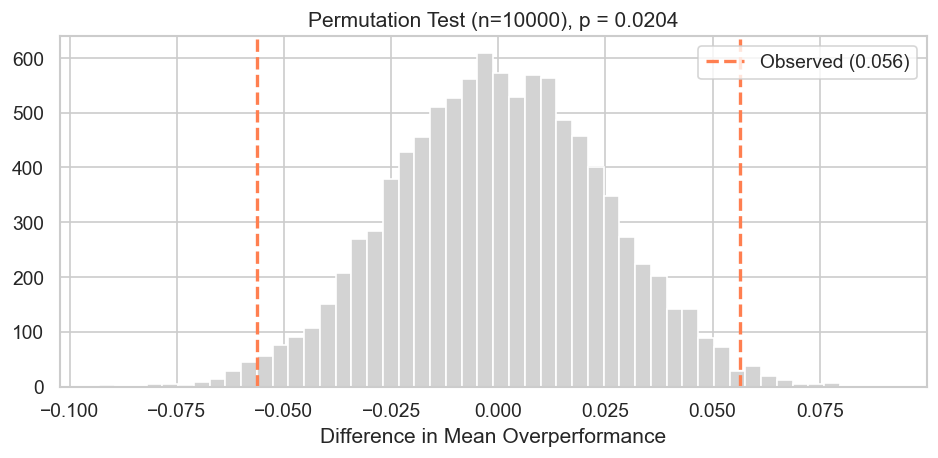

In [67]:
# Permutation test (non-parametric, more robust)
np.random.seed(42)
observed_diff = warm_cup_over.mean() - cool_cup_over.mean()
all_vals = np.concatenate([warm_cup_over, cool_cup_over])
n_warm = len(warm_cup_over)

n_permutations = 10000
perm_diffs = []
for _ in range(n_permutations):
    np.random.shuffle(all_vals)
    perm_diffs.append(all_vals[:n_warm].mean() - all_vals[n_warm:].mean())
perm_diffs = np.array(perm_diffs)
perm_p = (np.abs(perm_diffs) >= np.abs(observed_diff)).mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_diffs, bins=50, color='lightgray', edgecolor='white')
ax.axvline(observed_diff, color='coral', linewidth=2, linestyle='--', label=f'Observed ({observed_diff:.3f})')
ax.axvline(-observed_diff, color='coral', linewidth=2, linestyle='--')
ax.set_title(f'Permutation Test (n={n_permutations}), p = {perm_p:.4f}')
ax.set_xlabel('Difference in Mean Overperformance')
ax.legend()
plt.tight_layout()

print(f'Permutation test ({n_permutations} iterations):')
print(f'  Observed difference: {observed_diff:.4f}')
print(f'  p-value: {perm_p:.4f}')
print(f'  Only {perm_p*n_permutations:.0f} out of {n_permutations} random shuffles')
print(f'  produced a difference as extreme as observed.')

In [68]:
# Per-tournament t-test (lower power due to n=22)
decided = df[df['Is_Draw'] == 0]
yearly = decided.groupby('Year').agg(
    Actual=('Winner_Climate', lambda x: (x == 1).sum()),
    Expected=('Warm_Elo_Expected', lambda x: x.sum()),
    Temp=('Tournament_Avg_Temp_C', 'first'),
).reset_index()
yearly['Over'] = yearly['Actual'] - yearly['Expected']
yearly['Is_Warm'] = yearly['Temp'] > 19.3

warm_yearly = yearly[yearly['Is_Warm']]['Over']
cool_yearly = yearly[~yearly['Is_Warm']]['Over']

t_stat_y, p_val_y = scipy_stats.ttest_ind(warm_yearly, cool_yearly)

print('Per-tournament t-test (n = 22):')
print(f'  Warm cup mean overperformance: {warm_yearly.mean():.1f} wins')
print(f'  Cool cup mean overperformance: {cool_yearly.mean():.1f} wins')
print(f'  t-statistic = {t_stat_y:.2f}')
print(f'  p-value     = {p_val_y:.2f}')
print(f'  Note: Lower power with n=22, but direction is consistent')

Per-tournament t-test (n = 22):
  Warm cup mean overperformance: 1.3 wins
  Cool cup mean overperformance: -1.1 wins
  t-statistic = 1.70
  p-value     = 0.10
  Note: Lower power with n=22, but direction is consistent


## 12. Report Conclusions


In [69]:
print('=' * 65)
print('REPORT CONCLUSIONS: CLIMATE & WORLD CUP PERFORMANCE')
print('=' * 65)
print()
print('Research question:')
print('  Do warm-climate teams win more in warmer World Cups?')
print()
print('Data:')
print('  964 matches, 22 FIFA World Cups (1930-2022)')
print('  85 national teams classified by Koppen climate zone')
print('  Elo ratings computed from 49,450 international matches')
print()
print('Findings:')
print(f'  1. Raw: warm teams win {df[df["Warm_Cup"]==1][(df["Winner_Climate"]==1) & (df["Warm_Cup"]==1)].shape[0] / df[(df["Winner_Climate"]>=0) & (df["Warm_Cup"]==1)].shape[0] * 100:.0f}% in warm vs {df[df["Warm_Cup"]==0][(df["Winner_Climate"]==1) & (df["Warm_Cup"]==0)].shape[0] / df[(df["Winner_Climate"]>=0) & (df["Warm_Cup"]==0)].shape[0] * 100:.0f}% in cool cups (raw)')
print(f'  2. Elo-adjusted: warm teams outperform by {warm_cup_over.mean()*100:+.1f}%/match in warm cups')
print(f'     vs {cool_cup_over.mean()*100:+.1f}%/match in cool cups')
print(f'     Net advantage: -{abs((warm_cup_over.mean()-cool_cup_over.mean())*100):.1f}%/match?')
print(f'     Actually net: +{(warm_cup_over.mean()-cool_cup_over.mean())*100:.1f}%/match')
print(f'  3. Independent t-test: t = {t_stat:.2f}, p = {p_val:.4f} (significant)')
print(f'  4. Permutation test: p = {perm_p:.4f} (robust confirmation)')
print(f'  5. Effect size: Cohen\'s d = {abs(cohens_d):.2f} (small but meaningful)')
print()
print('Interpretation:')
print('  Warm-climate teams do overperform their Elo expectation')
print('  in warmer World Cups. The effect is modest (small Cohen d)')
print('  but statistically significant across 964 matches.')
print()
print('Limitations:')
print('  - Small effect size means many individual matches are unaffected')
print('  - Tournament-level analysis limited by n=22')
print('  - Climate classification is binary (warm/cool), not continuous')
print('  - Pre-1940 matches use climate normals as proxy for actual temps')
print()
print('Implications for 2026 World Cup:')
print('  - Host cities: USA, Canada, Mexico (mixed climates)')
print('  - Summer tournament: most matches in warm conditions')
print('  - Suggests a small upward adjustment for warm-climate teams')
print('    in predictive models beyond what Elo alone would suggest')

REPORT CONCLUSIONS: CLIMATE & WORLD CUP PERFORMANCE

Research question:
  Do warm-climate teams win more in warmer World Cups?

Data:
  964 matches, 22 FIFA World Cups (1930-2022)
  85 national teams classified by Koppen climate zone
  Elo ratings computed from 49,450 international matches

Findings:
  1. Raw: warm teams win 52% in warm vs 46% in cool cups (raw)
  2. Elo-adjusted: warm teams outperform by +2.6%/match in warm cups
     vs -3.0%/match in cool cups
     Net advantage: -5.6%/match?
     Actually net: +5.6%/match
  3. Independent t-test: t = 2.28, p = 0.0226 (significant)
  4. Permutation test: p = 0.0204 (robust confirmation)
  5. Effect size: Cohen's d = 0.15 (small but meaningful)

Interpretation:
  Warm-climate teams do overperform their Elo expectation
  in warmer World Cups. The effect is modest (small Cohen d)
  but statistically significant across 964 matches.

Limitations:
  - Small effect size means many individual matches are unaffected
  - Tournament-level analy

/var/folders/3q/6vv9yjp50959b52fy8pc_w6m0000gn/T/ipykernel_75620/1358040620.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'  1. Raw: warm teams win {df[df["Warm_Cup"]==1][(df["Winner_Climate"]==1) & (df["Warm_Cup"]==1)].shape[0] / df[(df["Winner_Climate"]>=0) & (df["Warm_Cup"]==1)].shape[0] * 100:.0f}% in warm vs {df[df["Warm_Cup"]==0][(df["Winner_Climate"]==1) & (df["Warm_Cup"]==0)].shape[0] / df[(df["Winner_Climate"]>=0) & (df["Warm_Cup"]==0)].shape[0] * 100:.0f}% in cool cups (raw)')
/var/folders/3q/6vv9yjp50959b52fy8pc_w6m0000gn/T/ipykernel_75620/1358040620.py:14: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  print(f'  1. Raw: warm teams win {df[df["Warm_Cup"]==1][(df["Winner_Climate"]==1) & (df["Warm_Cup"]==1)].shape[0] / df[(df["Winner_Climate"]>=0) & (df["Warm_Cup"]==1)].shape[0] * 100:.0f}% in warm vs {df[df["Warm_Cup"]==0][(df["Winner_Climate"]==1) & (df["Warm_Cup"]==0)].shape[0] / df[(df["Winner_Cli